# Clustering Penguins (Unsupervised ML)

**Task:** Cluster the Penguins dataset using numeric features and investigate the effect of **standardisation** and **normalisation** on clustering.

**Features used (numeric):**
- bill_length_mm *(or culmen_length_mm)*
- bill_depth_mm *(or culmen_depth_mm)*
- flipper_length_mm
- body_mass_g




# Unsupervised Machine Learning
## Clustering Penguins using K-Means

**Student Name:** Noor Saba  
**Module:** Standardisation & Normalisation  
**Algorithm Used:** K-Means  
**Evaluation Metric:** Adjusted Rand Index (ARI)

---

### Objectives

- Apply K-Means clustering
- Investigate the effect of feature scaling
- Compare clustering output to known species
- Visualise clusters using PCA

In [1]:
# Imports
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score

# Display settings (optional)
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.dpi'] = 120


## 1) Load the Penguins dataset

We will try:
1. `sns.load_dataset('penguins')` (includes `species`, `island`, `sex`)
2. If unavailable, fallback to the local file `penguins.csv`.

We also handle column naming differences:
- Seaborn uses `bill_length_mm`, `bill_depth_mm`
- Some CSV versions use `culmen_length_mm`, `culmen_depth_mm`


In [2]:
# Try to load the Seaborn dataset first
penguins = None
source = None

try:
    penguins = sns.load_dataset('penguins')
    source = "seaborn"
except Exception as e:
    # Fallback to the provided CSV
    csv_path = r"/mnt/data/penguins.csv"
    penguins = pd.read_csv(csv_path)
    source = "csv"

print("Loaded from:", source)
print(penguins.shape)
print(penguins.columns)

penguins.head()


Loaded from: seaborn
(344, 7)
Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## 2) Prepare features and target

### Cleaning steps
- Select the **numeric features** for clustering
- Drop rows with missing values in those features
- If `species` is present, keep it to evaluate how closely clusters correspond to species.

> Clustering is **unsupervised**, so we never train using `species`. We only use it later for evaluation.


In [3]:
# Define the numeric feature names (support both Seaborn and CSV naming)
feature_candidates = {
    "bill_length_mm": ["bill_length_mm", "culmen_length_mm"],
    "bill_depth_mm":  ["bill_depth_mm",  "culmen_depth_mm"],
    "flipper_length_mm": ["flipper_length_mm"],
    "body_mass_g": ["body_mass_g"],
}

# Resolve which columns exist in the loaded dataframe
resolved_features = {}
for canonical, options in feature_candidates.items():
    for col in options:
        if col in penguins.columns:
            resolved_features[canonical] = col
            break

# Check that we found all required columns
missing = [k for k in feature_candidates.keys() if k not in resolved_features]
if missing:
    raise ValueError(f"Missing required numeric columns: {missing}. Found: {penguins.columns.tolist()}")

# Build X from resolved feature columns
feature_cols = [resolved_features[k] for k in [
    "bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"
]]

# Keep species if present (for evaluation only)
has_species = "species" in penguins.columns

cols_to_keep = feature_cols + (["species"] if has_species else [])
work = penguins[cols_to_keep].copy()

# Drop missing values in the numeric features
work = work.dropna(subset=feature_cols)

X = work[feature_cols].astype(float)
y_true = work["species"] if has_species else None

print("Rows after dropping NA:", work.shape[0])
print("Feature columns used:", feature_cols)
print("Species available for evaluation?", has_species)

work.head()


Rows after dropping NA: 342
Feature columns used: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
Species available for evaluation? True


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species
0,39.1,18.7,181.0,3750.0,Adelie
1,39.5,17.4,186.0,3800.0,Adelie
2,40.3,18.0,195.0,3250.0,Adelie
4,36.7,19.3,193.0,3450.0,Adelie
5,39.3,20.6,190.0,3650.0,Adelie


## 3) Baseline KMeans clustering (no scaling)

We use **KMeans** with `k=3` because the classic penguins dataset has **3 species**.

>  KMeans is distance-based. Without scaling, features with larger numeric ranges (e.g., `body_mass_g`) can dominate the clustering.


In [4]:
# KMeans baseline (no scaling)
# random_state ensures reproducibility
kmeans_raw = KMeans(n_clusters=3, random_state=42, n_init="auto")
clusters_raw = kmeans_raw.fit_predict(X)

work["cluster_raw"] = clusters_raw

# Quick look at cluster sizes
work["cluster_raw"].value_counts().sort_index()


cluster_raw
0    117
1     81
2    144
Name: count, dtype: int64

### Compare clusters vs species (if available)

If `species` exists, we can compare using:
- A **cross-tab** (counts per species per cluster)
- **Adjusted Rand Index (ARI)**: 1 = perfect match, 0 ≈ random


In [5]:
if has_species:
    display(pd.crosstab(work["species"], work["cluster_raw"]))
    print("ARI (no scaling):", adjusted_rand_score(y_true, work["cluster_raw"]))
else:
    print("No 'species' column found in this dataset version, so ARI/crosstab cannot be computed.")
    print("You can still submit clustering + scaling analysis, or use Seaborn dataset that includes species.")


cluster_raw,0,1,2
species,,,
Adelie,53,0,98
Chinstrap,22,0,46
Gentoo,42,81,0


ARI (no scaling): 0.3100937047458321


## 4) Standardisation (Z-score scaling)

**StandardScaler** transforms each feature to:
- mean ≈ 0
- standard deviation ≈ 1

This usually improves KMeans because each feature contributes more equally to the distance calculation.


In [6]:
# Standardisation
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X)

kmeans_std = KMeans(n_clusters=3, random_state=42, n_init="auto")
clusters_std = kmeans_std.fit_predict(X_std)

work["cluster_std"] = clusters_std
work["cluster_std"].value_counts().sort_index()


cluster_std
0     87
1    123
2    132
Name: count, dtype: int64

In [7]:
if has_species:
    display(pd.crosstab(work["species"], work["cluster_std"]))
    print("ARI (standardised):", adjusted_rand_score(y_true, work["cluster_std"]))


cluster_std,0,1,2
species,,,
Adelie,24,0,127
Chinstrap,63,0,5
Gentoo,0,123,0


ARI (standardised): 0.7928369051321087


## 5) Normalisation (Min–Max scaling)

**MinMaxScaler** rescales each feature into the range **0 to 1**.

This can also help distance-based clustering, though sometimes standardisation performs better depending on the data distribution.


In [8]:
# Normalisation
scaler_mm = MinMaxScaler()
X_mm = scaler_mm.fit_transform(X)

kmeans_mm = KMeans(n_clusters=3, random_state=42, n_init="auto")
clusters_mm = kmeans_mm.fit_predict(X_mm)

work["cluster_minmax"] = clusters_mm
work["cluster_minmax"].value_counts().sort_index()


cluster_minmax
0     91
1    123
2    128
Name: count, dtype: int64

In [9]:
if has_species:
    display(pd.crosstab(work["species"], work["cluster_minmax"]))
    print("ARI (min-max):", adjusted_rand_score(y_true, work["cluster_minmax"]))


cluster_minmax,0,1,2
species,,,
Adelie,31,0,120
Chinstrap,60,0,8
Gentoo,0,123,0


ARI (min-max): 0.7356143605058111


## 6) Visualise clusters using PCA (2D)

We reduce the 4D feature space into 2 components using **PCA** and plot clusters.

> PCA here is **only for visualisation**, not required for clustering.


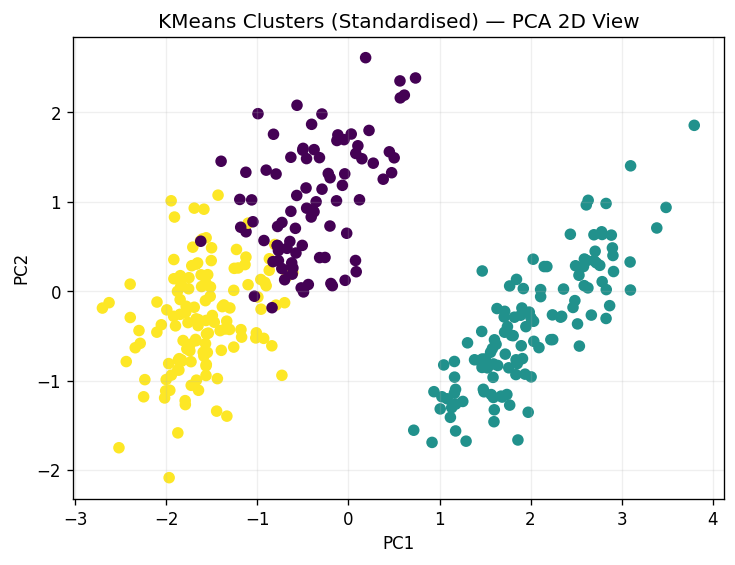

Explained variance ratio: [0.68843878 0.19312919]


In [10]:
# PCA visualisation on STANDARDISED features (recommended)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=work["cluster_std"], cmap="viridis", s=35)
plt.title("KMeans Clusters (Standardised) — PCA 2D View")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.2)
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)


## 7) Optional: Feature weighting

Sometimes one feature carries more signal for separating natural groups.
A simple experiment is to apply **weights** to standardised features.

Example idea:
- Increase weight for `flipper_length_mm` and `body_mass_g` (often strong separators for Gentoo)

> This is exploratory — report what you tried and the ARI result (if `species` exists).


In [11]:
# --- Feature weighting experiment (optional) ---
# Weights correspond to the order: [bill_length, bill_depth, flipper_length, body_mass]
weights = np.array([1.0, 1.0, 1.3, 1.3])

X_weighted = X_std * weights

kmeans_w = KMeans(n_clusters=3, random_state=42, n_init="auto")
clusters_w = kmeans_w.fit_predict(X_weighted)

work["cluster_weighted"] = clusters_w

if has_species:
    display(pd.crosstab(work["species"], work["cluster_weighted"]))
    print("ARI (weighted, std):", adjusted_rand_score(y_true, work["cluster_weighted"]))
else:
    print("Species not available; skipping ARI.")


cluster_weighted,0,1,2
species,,,
Adelie,30,0,121
Chinstrap,60,0,8
Gentoo,0,123,0


ARI (weighted, std): 0.7410646435510575


## 8) Conclusions

In your submission, summarise:

- **Baseline (no scaling):** often weaker because `body_mass_g` dominates distances.
- **Standardisation:** usually improves cluster quality in KMeans.
- **Normalisation:** can also help; results vary by dataset.
- **PCA plot:** shows how clusters separate in a 2D projection.
- **Evaluation:** if `species` is available, report ARI and a crosstab.

### What you should explicitly mention
- KMeans is **distance-based** → scaling matters.
- We do **not** use species to train (unsupervised).
- We use species only to **evaluate** how “meaningful” clusters are.
